Make ROOT independent of where the Jupyter server is launched:

In [1]:
from pathlib import Path

def find_project_root(start: Path, markers=("pyproject.toml", ".git")):
    for p in [start] + list(start.parents):
        if any((p / m).exists() for m in markers):
            return p
    raise RuntimeError("Project root not found")

ROOT = find_project_root(Path.cwd())

print(ROOT)

/home/urdatorn/git/gh/responsio-accentuum


In [2]:
from_cache = True

We need to make the distribution of strophicities in one metrically-responding-baseline statistic pass equal to the distribution of strophicities in Pindar.

We are focused only on the 40 macro-responding odes, so we need not bother with the 1-strophic is03, ol04, ol11, ol12, py07.

In [3]:
from collections import defaultdict
import matplotlib.pyplot as plt
from responsio_accentuum.utils.utils import get_strophicity

responsion_counts = get_strophicity()

# We check the number of odes for every strophicity
strophicities = defaultdict(int)
for strophicity in responsion_counts.values():
    strophicities[strophicity] += 1

strophicity_weights = {s: count/sum(strophicities.values()) for s, count in strophicities.items()}

for strophicity, count in sorted(strophicities.items()):
    print(f"{strophicity}-strophic: {count} odes ({strophicity_weights[strophicity]*100:.1f} percent); hence we need 6 * {count} = {6*count} permutations of data/compiled/baselines/baseline_aristophanes/tetra(and tri-)meter_{strophicity}.xml")

print(dict(strophicities))


2-strophic: 1 odes (2.5 percent); hence we need 6 * 1 = 6 permutations of data/compiled/baselines/baseline_aristophanes/tetra(and tri-)meter_2.xml
3-strophic: 10 odes (25.0 percent); hence we need 6 * 10 = 60 permutations of data/compiled/baselines/baseline_aristophanes/tetra(and tri-)meter_3.xml
4-strophic: 11 odes (27.5 percent); hence we need 6 * 11 = 66 permutations of data/compiled/baselines/baseline_aristophanes/tetra(and tri-)meter_4.xml
5-strophic: 13 odes (32.5 percent); hence we need 6 * 13 = 78 permutations of data/compiled/baselines/baseline_aristophanes/tetra(and tri-)meter_5.xml
6-strophic: 1 odes (2.5 percent); hence we need 6 * 1 = 6 permutations of data/compiled/baselines/baseline_aristophanes/tetra(and tri-)meter_6.xml
7-strophic: 1 odes (2.5 percent); hence we need 6 * 1 = 6 permutations of data/compiled/baselines/baseline_aristophanes/tetra(and tri-)meter_7.xml
11-strophic: 1 odes (2.5 percent); hence we need 6 * 1 = 6 permutations of data/compiled/baselines/baselin

1-strophic: 5 odes
2-strophic: 1 odes
3-strophic: 10 odes
4-strophic: 11 odes
5-strophic: 13 odes
6-strophic: 1 odes 
7-strophic: 1 odes 
11-strophic: 1 odes
12-strophic: 1 odes
13-strophic: 1 odes

Prepare first version of all the higher un-manual strophicities:

In [4]:
import os
import re

def make_higher_strophicity(xml_file_path, flavour="tetrameter"):
    xml_path = Path(xml_file_path)
    text = xml_path.read_text(encoding="utf8")

    # extract all <l> elements from ALL canticum blocks
    lines = re.findall(r"<l\b[^>]*>.*?</l>", text, flags=re.DOTALL)                     # the DOTALL flag makes the DOT . find ALL chars including \n
    # filter to unique <l> elements based on inner text
    seen = set()
    unique_lines = []
    line_metadata = []  # Track (canticum, original_strophe, line_in_strophe) for each line

    for l in lines:
        inner = re.sub(r"<l\b[^>]*>|</l>", "", l, flags=re.DOTALL)                      # the DOTALL flag makes the DOT . find ALL chars including \n
        if inner not in seen:
            seen.add(inner)
            unique_lines.append(l)

            # Parse the 'n' attribute to extract metadata (used only for tetrameter constraints)
            match = re.search(r' n="([^"]*)"', l)
            if match:
                n_val = match.group(1)
                parts = n_val.split('_')
                try:
                    canticum = parts[0]
                    strophe_line_part = parts[1]
                    original_strophe = int(strophe_line_part.split('-')[0])
                    line_in_strophe = int(strophe_line_part.split('-')[1])
                    line_metadata.append((canticum, original_strophe, line_in_strophe))
                except Exception:
                    line_metadata.append(None)
            else:
                line_metadata.append(None)

    lines = unique_lines

    # Build responsion groups: (canticum, line_in_strophe) -> list of line indices
    responsion_groups = {}
    for idx, meta in enumerate(line_metadata):
        if meta:
            canticum, original_strophe, line_in_strophe = meta
            key = (canticum, line_in_strophe)
            if key not in responsion_groups:
                responsion_groups[key] = []
            responsion_groups[key].append(idx)

    # Filter to only groups where lines originally responded (>1 line per group)
    responsion_groups = {k: v for k, v in responsion_groups.items() if len(v) > 1}

    # We only need baselines with strophicities present in Pindar (and 2 is the source)
    for n_strophes in [3, 4, 5, 6, 7, 11, 12, 13]:

        # split lines evenly — truncate excess so all strophes have equal line counts
        chunk_size = len(lines) // n_strophes
        usable = chunk_size * n_strophes
        lines_to_use = lines[:usable]

        if flavour == "tetrameter":
            # Distribute lines using constraint-aware greedy algorithm.
            # Ensure originally responding lines do not end up at the same position in different new strophes.
            chunks = [[] for _ in range(n_strophes)]
            position_tracker = [[None] * chunk_size for _ in range(n_strophes)]  # Tracks original line index at each position
            used_indices = set()

            for strophe_idx in range(n_strophes):
                for pos_idx in range(chunk_size):
                    # Find a line to place at this position that does not violate constraints.
                    placed = False
                    for line_idx in range(len(lines_to_use)):
                        if line_idx in used_indices:
                            continue

                        # Check if placing this line violates the responsion constraint.
                        violates = False
                        for prev_strophe_idx in range(strophe_idx):
                            prev_line_idx_at_pos = position_tracker[prev_strophe_idx][pos_idx]
                            if prev_line_idx_at_pos is not None:
                                # Check if these two lines originally responded.
                                for responding_group in responsion_groups.values():
                                    if line_idx in responding_group and prev_line_idx_at_pos in responding_group:
                                        violates = True
                                        break
                                if violates:
                                    break

                        if not violates:
                            chunks[strophe_idx].append(lines_to_use[line_idx])
                            position_tracker[strophe_idx][pos_idx] = line_idx
                            used_indices.add(line_idx)
                            placed = True
                            break

                    if not placed:
                        raise RuntimeError(
                            f"Constraint-satisfying placement failed for {xml_path.name} ({flavour}), "
                            f"{n_strophes}-strophic output, strophe {strophe_idx + 1}, "
                            f"line position {pos_idx + 1}. No unused line can be placed "
                            "without recreating original responsion."
                        )
        else:
            # Trimeter has no usable n-metadata for anti-responsion constraints; keep unconstrained chunking.
            chunks = []
            i = 0
            for _ in range(n_strophes):
                chunks.append(lines_to_use[i:i + chunk_size])
                i += chunk_size

        # build strophe blocks
        strophe_blocks = []
        for idx, chunk in enumerate(chunks):

            typ = "strophe"

            # indent the <l> lines
            indented_lines = "\n".join("          " + l for l in chunk)

            if flavour == "tetrameter":
                block = (
                    f'        <strophe type="{typ}" responsion="lyricbaseline{n_strophes:02d}">\n'
                    + indented_lines +
                    "\n        </strophe>"
                )

            elif flavour == "trimeter":
                block = (
                    f'        <strophe type="{typ}" responsion="dialoguebaseline{n_strophes:02d}">\n'
                    + indented_lines +
                    "\n        </strophe>"
                )

            strophe_blocks.append(block)

        # assemble new canticum
        new_canticum = (
            "      <canticum>\n"
            + "\n".join(strophe_blocks)
            + "\n      </canticum>"
        )

        # update title
        if flavour == "tetrameter":
            new_text = re.sub(
                r"<title>.*?</title>",
                f"<title>{n_strophes}-strophic Tetrameter Baseline</title>",
                text,
                flags=re.DOTALL
            )

        elif flavour == "trimeter":
            new_text = re.sub(
                r"<title>.*?</title>",
                f"<title>{n_strophes}-strophic Trimeter (Dialogue) Baseline</title>",
                text,
                flags=re.DOTALL
            )

        # remove all original canticum blocks cleanly
        new_text = re.sub(
            r"\s*<canticum>.*?</canticum>\s*",
            "\n",
            new_text,
            flags=re.DOTALL
        )

        # insert the new canticum before </body>
        new_text = re.sub(
            r"\s*</body>",
            "\n" + new_canticum + "\n    </body>",
            new_text,
            count=1
        )

        # write output
        out_path = xml_path.with_name(f"{flavour}_{n_strophes}.xml")
        out_path.write_text(new_text, encoding="utf8")

if not os.path.exists(ROOT / "data/cache/aristophanes_bl_statistics.pkl"):
    make_higher_strophicity(ROOT / "data" / "compiled" / "baselines" / "baseline_aristophanes" / "tetrameter_2.xml", "tetrameter")
    make_higher_strophicity(ROOT / "data" / "compiled" / "baselines" / "baseline_aristophanes" / "trimeter_2.xml", "trimeter")

We need to check that all the files are metrically sound.

In [5]:
from lxml import etree
from responsio_accentuum import canonical_sylls, metrically_responding_lines_polystrophic

baseline_files = []
for n in [2, 3, 4, 5, 6, 7, 11, 12, 13]:
    tetrameter = ROOT / f"data/compiled/baselines/baseline_aristophanes/tetrameter_{n}.xml"
    trimeter = ROOT / f"data/compiled/baselines/baseline_aristophanes/trimeter_{n}.xml"
    baseline_files.append(tetrameter)
    baseline_files.append(trimeter)

all_ok = True

for bf in baseline_files:
    tree = etree.parse(str(bf))
    strophes = tree.xpath('//strophe')

    # Group strophes by @responsion
    responsion_groups = {}
    for s in strophes:
        rid = s.get('responsion')
        responsion_groups.setdefault(rid, []).append(s)

    for rid, group in responsion_groups.items():
        # Get lines from each strophe
        strophe_lines = [s.findall('l') for s in group]
        n_lines = [len(ls) for ls in strophe_lines]

        # Check all strophes have same number of lines
        if len(set(n_lines)) != 1:
            print(f"FAIL {bf.name} [{rid}]: strophes have different line counts: {n_lines}")
            all_ok = False
            continue

        # For each line position, check canonical_sylls length and metrical responsion
        for i in range(n_lines[0]):
            responding = [ls[i] for ls in strophe_lines]
            lengths = [len(canonical_sylls(l)) for l in responding]

            if len(set(lengths)) != 1:
                line_ns = [l.get('n', '?') for l in responding]
                print(f"FAIL {bf.name} [{rid}] pos {i}: canonical_sylls lengths differ: {dict(zip(line_ns, lengths))}")
                all_ok = False

            if not metrically_responding_lines_polystrophic(*responding):
                line_ns = [l.get('n', '?') for l in responding]
                print(f"FAIL {bf.name} [{rid}] pos {i}: metrical responsion fails for lines {line_ns}")
                all_ok = False

if all_ok:
    print("All baseline files are metrically sound!")

All baseline files are metrically sound!


Define the permutation functions...

In [6]:
from math import gamma as Γ
import random
import re
from typing import Iterator

baseline_files = []
for n in [2, 3, 4, 5, 6, 7, 11, 12, 13]:
    tetrameter = ROOT / f"data/compiled/baselines/baseline_aristophanes/tetrameter_{n}.xml"
    trimeter = ROOT / f"data/compiled/baselines/baseline_aristophanes/trimeter_{n}.xml"
    baseline_files.append(tetrameter)
    baseline_files.append(trimeter)

# Make permutated versions of all canticum elements in each of the six files.
# Important points:
# - What's permuted are the l element orderings of each of its strophes.
# - It is key that the permutation is different for all strophes inside the same canticum, so responsion is not conserved, otherwise the permutation test will not work
# - There are n! possible permutations for a strophe with n lines
# - 8! is the smallest factorial > 10 000,
#   so 13-strophic songs would need to be 8-lined at least to enable 10k permutations.
# - But they are 3-lined, hence we can only do 6 permutations.
# - Comic tetrameters are capped out so increasing is only an option for trimeters.

factorial = lambda n: int(Γ(n + 1))
permutations = factorial(3) # max permutations of the 13-strophic baseline odes

temp_dir = ROOT / "data/compiled/baselines/baseline_aristophanes/temp_permutations"

canticum_re = re.compile(r"(<canticum\b[^>]*>)(.*?)(</canticum>)", re.S)
strophe_re = re.compile(r"(<strophe\b[^>]*>)(.*?)(</strophe>)", re.S)

def parse_source_key_from_l_line(l_line: str) -> tuple[str, int] | None:
    """Return (source_canticum, source_internal_line_nr) parsed from @n, else None."""
    m = re.search(r'\bn="([^"]+)"', l_line)
    if not m:
        return None
    n_val = m.group(1)
    parts = n_val.split("_")
    if len(parts) < 2:
        return None
    try:
        source_canticum = parts[0]
        strophe_internal = parts[1]  # e.g. 1-3
        internal_line_nr = int(strophe_internal.split("-")[1])
        return (source_canticum, internal_line_nr)
    except Exception:
        return None

def extract_strophe_structures(canticum_body: str):
    """Parse strophe bodies and keep mutable split-lines representation for replacement."""
    structures = []
    for sm in strophe_re.finditer(canticum_body):
        strophe_open, strophe_body, strophe_close = sm.groups()
        lines = strophe_body.splitlines(keepends=True)
        l_indices = [i for i, line in enumerate(lines) if re.search(r"<l\b", line)]
        structures.append(
            {
                "open": strophe_open,
                "close": strophe_close,
                "lines": lines,
                "l_indices": l_indices,
            }
        )
    return structures

def tetrameter_constraint_holds(text: str) -> bool:
    """Check: within each output canticum, same line position across strophes cannot reuse same source key."""
    for c_match in canticum_re.finditer(text):
        c_body = c_match.group(2)
        strophes = extract_strophe_structures(c_body)
        if not strophes:
            continue

        max_positions = max((len(s["l_indices"]) for s in strophes), default=0)
        for pos_idx in range(max_positions):
            seen_keys = set()
            for s in strophes:
                if pos_idx >= len(s["l_indices"]):
                    continue
                line_idx = s["l_indices"][pos_idx]
                l_line = s["lines"][line_idx]
                key = parse_source_key_from_l_line(l_line)
                if key is None:
                    continue
                if key in seen_keys:
                    return False
                seen_keys.add(key)
    return True

def shuffle_strophe_lines(strophe_body: str, rng: random.Random) -> str:
    # Trimeter path: original unconstrained per-strophe shuffle.
    lines = strophe_body.splitlines(keepends=True)

    l_indices = [i for i, line in enumerate(lines) if re.search(r"<l\b", line)]

    if len(l_indices) <= 1:
        return strophe_body

    l_lines = [lines[i] for i in l_indices]
    rng.shuffle(l_lines)

    for idx, new_line in zip(l_indices, l_lines):
        lines[idx] = new_line

    return "".join(lines)

def permute_tetrameter_once(text: str, rng: random.Random, max_attempts: int = 200) -> str:
    # Build mutable canticum/strophe structures.
    canticum_structs = []
    all_l_lines = []

    for c_idx, c_match in enumerate(canticum_re.finditer(text)):
        c_open, c_body, c_close = c_match.groups()
        strophes = extract_strophe_structures(c_body)

        for s in strophes:
            for li in s["l_indices"]:
                all_l_lines.append(s["lines"][li])

        canticum_structs.append(
            {
                "open": c_open,
                "close": c_close,
                "body": c_body,
                "strophes": strophes,
            }
        )

    if len(all_l_lines) <= 1:
        return text

    source_keys = [parse_source_key_from_l_line(l) for l in all_l_lines]

    # Define target slots as (canticum_index, strophe_index, position_in_strophe).
    slots = []
    for c_idx, c in enumerate(canticum_structs):
        for s_idx, s in enumerate(c["strophes"]):
            for pos_idx in range(len(s["l_indices"])):
                slots.append((c_idx, s_idx, pos_idx))

    if len(slots) != len(all_l_lines):
        raise RuntimeError("Internal mismatch: number of slots differs from number of lines")

    for _ in range(max_attempts):
        remaining = list(range(len(all_l_lines)))
        rng.shuffle(remaining)

        used_source_keys = {}  # (canticum_idx, pos_idx) -> set of source keys
        assignment = {}         # (canticum_idx, s_idx, pos_idx) -> line_pool_idx
        success = True

        for c_idx, s_idx, pos_idx in slots:
            group_key = (c_idx, pos_idx)
            group_used = used_source_keys.setdefault(group_key, set())

            chosen_pos = None
            for rem_i, pool_idx in enumerate(remaining):
                src_key = source_keys[pool_idx]
                if src_key is not None and src_key in group_used:
                    continue
                chosen_pos = rem_i
                break

            if chosen_pos is None:
                success = False
                break

            chosen_pool_idx = remaining.pop(chosen_pos)
            assignment[(c_idx, s_idx, pos_idx)] = chosen_pool_idx
            src_key = source_keys[chosen_pool_idx]
            if src_key is not None:
                group_used.add(src_key)

        if not success:
            continue

        # Apply assignment to mutable strophe lines.
        for (c_idx, s_idx, pos_idx), pool_idx in assignment.items():
            s = canticum_structs[c_idx]["strophes"][s_idx]
            line_array_idx = s["l_indices"][pos_idx]
            s["lines"][line_array_idx] = all_l_lines[pool_idx]

        # Rebuild each canticum body while preserving non-strophe text segments.
        rebuilt_canticum_texts = []
        for c in canticum_structs:
            rebuilt_strophes = [
                s["open"] + "".join(s["lines"]) + s["close"]
                for s in c["strophes"]
            ]
            rebuilt_iter = iter(rebuilt_strophes)
            new_body = strophe_re.sub(lambda m: next(rebuilt_iter), c["body"])
            rebuilt_canticum_texts.append(c["open"] + new_body + c["close"])

        # Rebuild full text while preserving non-canticum segments.
        c_iter = iter(rebuilt_canticum_texts)
        new_text = canticum_re.sub(lambda m: next(c_iter), text)

        # Final sanity check for the tetrameter-specific constraint.
        assert tetrameter_constraint_holds(new_text), "Tetrameter anti-responsion constraint violated"
        return new_text

    raise RuntimeError(
        "Could not find a tetrameter permutation satisfying anti-responsion constraints "
        f"after {max_attempts} attempts"
    )

def permute_text_once(text: str, rng: random.Random, flavour: str = "trimeter") -> str:
    if flavour == "tetrameter":
        return permute_tetrameter_once(text, rng)

    # Trimeter behavior remains unchanged.
    def repl(match):
        open_tag, body, close_tag = match.groups()
        new_body = shuffle_strophe_lines(body, rng)
        return open_tag + new_body + close_tag

    return strophe_re.sub(repl, text)

def iter_permuted_texts(
    xml_path: Path,
    n_permutations: int,
    seed: int | None = None,
    skip_existing: bool = False,
    output_dir: Path = None,
    stem: str = None,
    flavour: str | None = None,
    ) -> Iterator[tuple[int, str]]:
    text = xml_path.read_text(encoding="utf-8")
    rng = random.Random(seed)

    inferred_flavour = flavour
    if inferred_flavour is None:
        if xml_path.stem.startswith("tetrameter"):
            inferred_flavour = "tetrameter"
        else:
            inferred_flavour = "trimeter"

    for i in range(1, n_permutations + 1):
        if skip_existing and output_dir is not None and stem is not None:
            out_path = output_dir / f"{stem}_perm_{i:05d}.xml"
            if out_path.exists():
                continue

        permuted = permute_text_once(text, rng, flavour=inferred_flavour)
        if inferred_flavour == "tetrameter":
            # Final assert requested by user.
            assert tetrameter_constraint_holds(permuted), "Tetrameter anti-responsion constraint violated"
        yield i, permuted

def save_permutations(
    xml_path: Path,
    n_permutations: int,
    output_dir: Path,
    seed: int | None = None,
    ) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)
    stem = xml_path.stem
    flavour = "tetrameter" if stem.startswith("tetrameter") else "trimeter"
    for i, permuted_text in iter_permuted_texts(
        xml_path,
        n_permutations,
        seed=seed,
        skip_existing=True,
        output_dir=output_dir,
        stem=stem,
        flavour=flavour,
    ):
        out_path = output_dir / f"{stem}_perm_{i:05d}.xml"
        out_path.write_text(permuted_text, encoding="utf-8")

def print_test_permutation(xml_path: Path) -> None:
    flavour = "tetrameter" if xml_path.stem.startswith("tetrameter") else "trimeter"
    text = next(iter_permuted_texts(xml_path, 1, seed=42, flavour=flavour))[1]
    print(text[:10000])

In [7]:
# Test print of one permutation to inspect
print_test_permutation(baseline_files[17])

<?xml version='1.0' encoding='UTF-8'?>
<TEI>
  <teiHeader>
    <fileDesc>
      <titleStmt>
        <title>13-strophic Trimeter (Dialogue) Baseline</title>
        <author>Aristophanes</author>
      </titleStmt>
    </fileDesc>
  </teiHeader>
  <text>
    <body>
      <canticum>
        <strophe type="strophe" responsion="dialoguebaseline13">
          <l n="2" metre=""><syll weight="heavy" anceps="True">ἥσ</syll><syll weight="heavy">θην</syll> <syll weight="light">δὲ</syll> <syll weight="heavy">βαι</syll><syll weight="light" anceps="True">ά</syll>, <syll weight="light" resolution="True">πά</syll><syll weight="light" resolution="True">νυ</syll> <syll weight="light">δὲ</syll> <syll weight="heavy">βαι</syll><syll weight="light" anceps="True">ά</syll>, <syll weight="heavy">τέτ</syll><syll weight="light">τα</syll><syll weight="light" brevis_in_longo="True">ρα</syll>· </l>
          <l n="1" metre=""><syll weight="light" resolution="True">Ὅ</syll><syll weight="light" resolution="True">σα</

...and time to permute and save to disk! We permute each class enough times to maintain the Pindaric corpus distribution of strophicities.

In [8]:
if not from_cache:

    import hashlib
    import re
    from tqdm import tqdm

    # determines number of output expected test statistics
    base_cycles = 10_000
    strophicity_counts = {
        2: 1,
        3: 10,
        4: 11,
        5: 13,
        6: 1,
        7: 1,
        11: 1,
        12: 1,
        13: 1,
    }

    generated_paths = []
    for file in tqdm(baseline_files):
        m = re.search(r"_(\d+)\.xml$", file.name)
        if not m:
            raise ValueError(f"Could not infer strophicity from filename: {file.name}")

        strophicity = int(m.group(1))
        if strophicity not in strophicity_counts:
            raise ValueError(f"Unexpected strophicity {strophicity} in {file.name}")

        n_permutations = base_cycles * strophicity_counts[strophicity]
        save_permutations(
            file,
            n_permutations=n_permutations,
            output_dir=temp_dir / file.stem,
            seed=1453,
        )
        generated_paths.extend(sorted((temp_dir / file.stem).glob("*.xml")))

    # Quick uniqueness check of generated XML content
    hash_to_files = {}
    for path in generated_paths:
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        hash_to_files.setdefault(digest, []).append(path)

    duplicate_groups = [paths for paths in hash_to_files.values() if len(paths) > 1]
    if duplicate_groups:
        print(f"Found {len(duplicate_groups)} duplicate content group(s) among generated XMLs.")
        for group in duplicate_groups[:5]:
            print("  Duplicate group:")
            for p in group:
                print(f"    - {p}")
    else:
        print(f"All generated XMLs are unique by content ({len(generated_paths)} files checked).")

The plan is this: to calculate one test statistic we collect 40 songs by pooling 1 2-strophic ode, 10 3-strophic odes, etc. 

We then repeat this 10k times.

The final value presented in the table in the article will be the mean of these 10k test statistics, just like for the shape-preserving baselines.

In [9]:
if not from_cache:

    from responsio_accentuum import compatibility_play, compatibility_ratios_to_stats

    ########################
    test_statistics = 10_000
    ########################

    expected_statistics_tetrameter = {}
    for n in tqdm(range(1, test_statistics+1)):
        # 1. Pool 40 bl songs with the right strophicity distribution
        pool = []
        
        # For strophicity 2, get the nth permutation only
        strophicity_2 = compatibility_play(ROOT / temp_dir / f"tetrameter_2" / f"tetrameter_2_perm_{n:05d}.xml")
        pool.extend(strophicity_2)
        # For strophicity 3, get the nth to (n + 9)th permutations
        for m in range(n, n + 10):
            strophicity_3 = compatibility_play(ROOT / temp_dir / f"tetrameter_3" / f"tetrameter_3_perm_{m:05d}.xml")
            pool.extend(strophicity_3)
        # For strophicity 4, get the nth to (n + 10)th permutations
        for m in range(n, n + 11):
            strophicity_4 = compatibility_play(ROOT / temp_dir / f"tetrameter_4" / f"tetrameter_4_perm_{m:05d}.xml")
            pool.extend(strophicity_4)
        # For strophicity 5, get the nth to (n + 12)th permutations
        for m in range(n, n + 13):
            strophicity_5 = compatibility_play(ROOT / temp_dir / f"tetrameter_5" / f"tetrameter_5_perm_{m:05d}.xml")
            pool.extend(strophicity_5)
        # For strophicity 6, get the nth permutation only
        strophicity_6 = compatibility_play(ROOT / temp_dir / f"tetrameter_6" / f"tetrameter_6_perm_{n:05d}.xml")
        pool.extend(strophicity_6)
        # For strophicity 7, get the nth permutation only
        strophicity_7 = compatibility_play(ROOT / temp_dir / f"tetrameter_7" / f"tetrameter_7_perm_{n:05d}.xml")
        pool.extend(strophicity_7)
        # For strophicity 11, get the nth permutation only
        strophicity_11 = compatibility_play(ROOT / temp_dir / f"tetrameter_11" / f"tetrameter_11_perm_{n:05d}.xml")
        pool.extend(strophicity_11)
        # For strophicity 12, get the nth permutation only
        strophicity_12 = compatibility_play(ROOT / temp_dir / f"tetrameter_12" / f"tetrameter_12_perm_{n:05d}.xml")
        pool.extend(strophicity_12)
        # For strophicity 13, get the nth permutation only
        strophicity_13 = compatibility_play(ROOT / temp_dir / f"tetrameter_13" / f"tetrameter_13_perm_{n:05d}.xml")
        pool.extend(strophicity_13)
        
        if len(pool) != 40:
            raise ValueError(f"Expected 40 songs in pool for n={n}, but got {len(pool)}")
        
        # 2. Calculate compatibility of the pool and save
        statistic = compatibility_ratios_to_stats(pool)
        expected_statistics_tetrameter[n] = statistic

    # Calculate final mean statistic across the 6 corpora
    mean = sum(expected_statistics_tetrameter.values()) / len(expected_statistics_tetrameter)

    print("#" * 40)
    print("TETRAMETER")
    print("#" * 40)
    print()

    print(f"Mean expected statistic across 6 corpora: \033[92m{mean:.4f}\033[0m\n")
        
    expected_statistics_trimeter = {}
    for n in tqdm(range(1, test_statistics+1)):
        # 1. Pool 40 bl songs with the right strophicity distribution
        pool = []
        
        # For strophicity 2, get the nth permutation only
        strophicity_2 = compatibility_play(ROOT / temp_dir / f"trimeter_2" / f"trimeter_2_perm_{n:05d}.xml")
        pool.extend(strophicity_2)
        # For strophicity 3, get the nth to (n + 9)th permutations
        for m in range(n, n + 10):
            strophicity_3 = compatibility_play(ROOT / temp_dir / f"trimeter_3" / f"trimeter_3_perm_{m:05d}.xml")
            pool.extend(strophicity_3)
        # For strophicity 4, get the nth to (n + 10)th permutations
        for m in range(n, n + 11):
            strophicity_4 = compatibility_play(ROOT / temp_dir / f"trimeter_4" / f"trimeter_4_perm_{m:05d}.xml")
            pool.extend(strophicity_4)
        # For strophicity 5, get the nth to (n + 12)th permutations
        for m in range(n, n + 13):
            strophicity_5 = compatibility_play(ROOT / temp_dir / f"trimeter_5" / f"trimeter_5_perm_{m:05d}.xml")
            pool.extend(strophicity_5)
        # For strophicity 6, get the nth permutation only
        strophicity_6 = compatibility_play(ROOT / temp_dir / f"trimeter_6" / f"trimeter_6_perm_{n:05d}.xml")
        pool.extend(strophicity_6)
        # For strophicity 7, get the nth permutation only
        strophicity_7 = compatibility_play(ROOT / temp_dir / f"trimeter_7" / f"trimeter_7_perm_{n:05d}.xml")
        pool.extend(strophicity_7)
        # For strophicity 11, get the nth permutation only
        strophicity_11 = compatibility_play(ROOT / temp_dir / f"trimeter_11" / f"trimeter_11_perm_{n:05d}.xml")
        pool.extend(strophicity_11)
        # For strophicity 12, get the nth permutation only
        strophicity_12 = compatibility_play(ROOT / temp_dir / f"trimeter_12" / f"trimeter_12_perm_{n:05d}.xml")
        pool.extend(strophicity_12)
        # For strophicity 13, get the nth permutation only
        strophicity_13 = compatibility_play(ROOT / temp_dir / f"trimeter_13" / f"trimeter_13_perm_{n:05d}.xml")
        pool.extend(strophicity_13)
        
        if len(pool) != 40:
            raise ValueError(f"Expected 40 songs in pool for n={n}, but got {len(pool)}")
        
        # 2. Calculate compatibility of the pool and save
        statistic = compatibility_ratios_to_stats(pool)
        expected_statistics_trimeter[n] = statistic
        
    # Calculate final mean statistic across the corpora
    mean = sum(expected_statistics_trimeter.values()) / len(expected_statistics_trimeter)

    print()
    print("#" * 40)
    print("TRIMETER")
    print("#" * 40)
    print()

    print(f"Mean expected statistic across {test_statistics} corpora: \033[92m{mean:.4f}\033[0m\n")

In [10]:
if not from_cache:
    import pickle

    with open(ROOT / "data/cache/aristophanes_bl_statistics.pkl", "wb") as f:
        pickle.dump(
            {
                "tetrameter": expected_statistics_tetrameter,
                "trimeter": expected_statistics_trimeter,
            },
            f
        )

In [11]:
import os
import pickle

if os.path.exists(ROOT / "data/cache/aristophanes_bl_statistics.pkl"):
    with open(ROOT / "data/cache/aristophanes_bl_statistics.pkl", "rb") as f:
        stats = pickle.load(f)

expected_statistics_tetrameter = stats["tetrameter"]
expected_statistics_trimeter = stats["trimeter"]

# Calculate final mean statistic across the corpora
mean = sum(expected_statistics_tetrameter.values()) / len(expected_statistics_tetrameter)

print("#" * 40)
print("TETRAMETER")
print("#" * 40)
print()

print(f"Mean expected statistic across 10k corpora: \033[92m{mean:.4f}\033[0m\n")
print(f"Minimum: \033[92m{min(expected_statistics_tetrameter.values()):.4f}\033[0m")
print(f"Maximum: \033[92m{max(expected_statistics_tetrameter.values()):.4f}\033[0m")

# Calculate final mean statistic across the corpora
mean = sum(expected_statistics_trimeter.values()) / len(expected_statistics_trimeter)

print()
print("#" * 40)
print("TRIMETER")
print("#" * 40)
print()

print(f"Mean expected statistic across 10k corpora: \033[92m{mean:.4f}\033[0m\n")
print(f"Minimum: \033[92m{min(expected_statistics_trimeter.values()):.4f}\033[0m")
print(f"Maximum: \033[92m{max(expected_statistics_trimeter.values()):.4f}\033[0m")



########################################
TETRAMETER
########################################

Mean expected statistic across 10k corpora: 0.4781

Minimum: 0.4645
Maximum: 0.4911

########################################
TRIMETER
########################################

Mean expected statistic across 10k corpora: 0.4236

Minimum: 0.4119
Maximum: 0.4378


## One-sided permutation test

In [12]:
'''
One observed test statistics: 
T_obs_triads

Two lists of expected test statistics:
expected_statistics_tetrameter,
expected_statistics_trimeter

The observed value will be compared to the distributions of expected statistics from the two baselines, to get two p-values.
'''

import numpy as np

T_obs_triads = 0.4116

T_exp_triads_tetrameter = list(expected_statistics_tetrameter.values())
T_exp_triads_trimeter = list(expected_statistics_trimeter.values())

def permutation_p_value(T_obs, baseline):
    baseline_arr = np.asarray(baseline)
    ge_count = np.sum(baseline_arr >= T_obs) # ge = greater than or equal to
    return (1 + ge_count) / (1 + baseline_arr.size) # convention to add 1 to numerator and denominator to avoid zero p-value (source: https://en.wikipedia.org/wiki/P-value#Permutation_tests)

p_tetrameter = permutation_p_value(T_obs_triads, T_exp_triads_tetrameter)
p_trimeter = permutation_p_value(T_obs_triads, T_exp_triads_trimeter)

print(f"p_tetrameter (triads vs tetrameter baseline): \033[1m{p_tetrameter:.30f}\033[0m")
print(f"p_trimeter (triads vs trimeter baseline): \033[1m{p_trimeter:.30f}\033[0m")

p_tetrameter (triads vs tetrameter baseline): 1.000000000000000000000000000000
p_trimeter (triads vs trimeter baseline): 1.000000000000000000000000000000


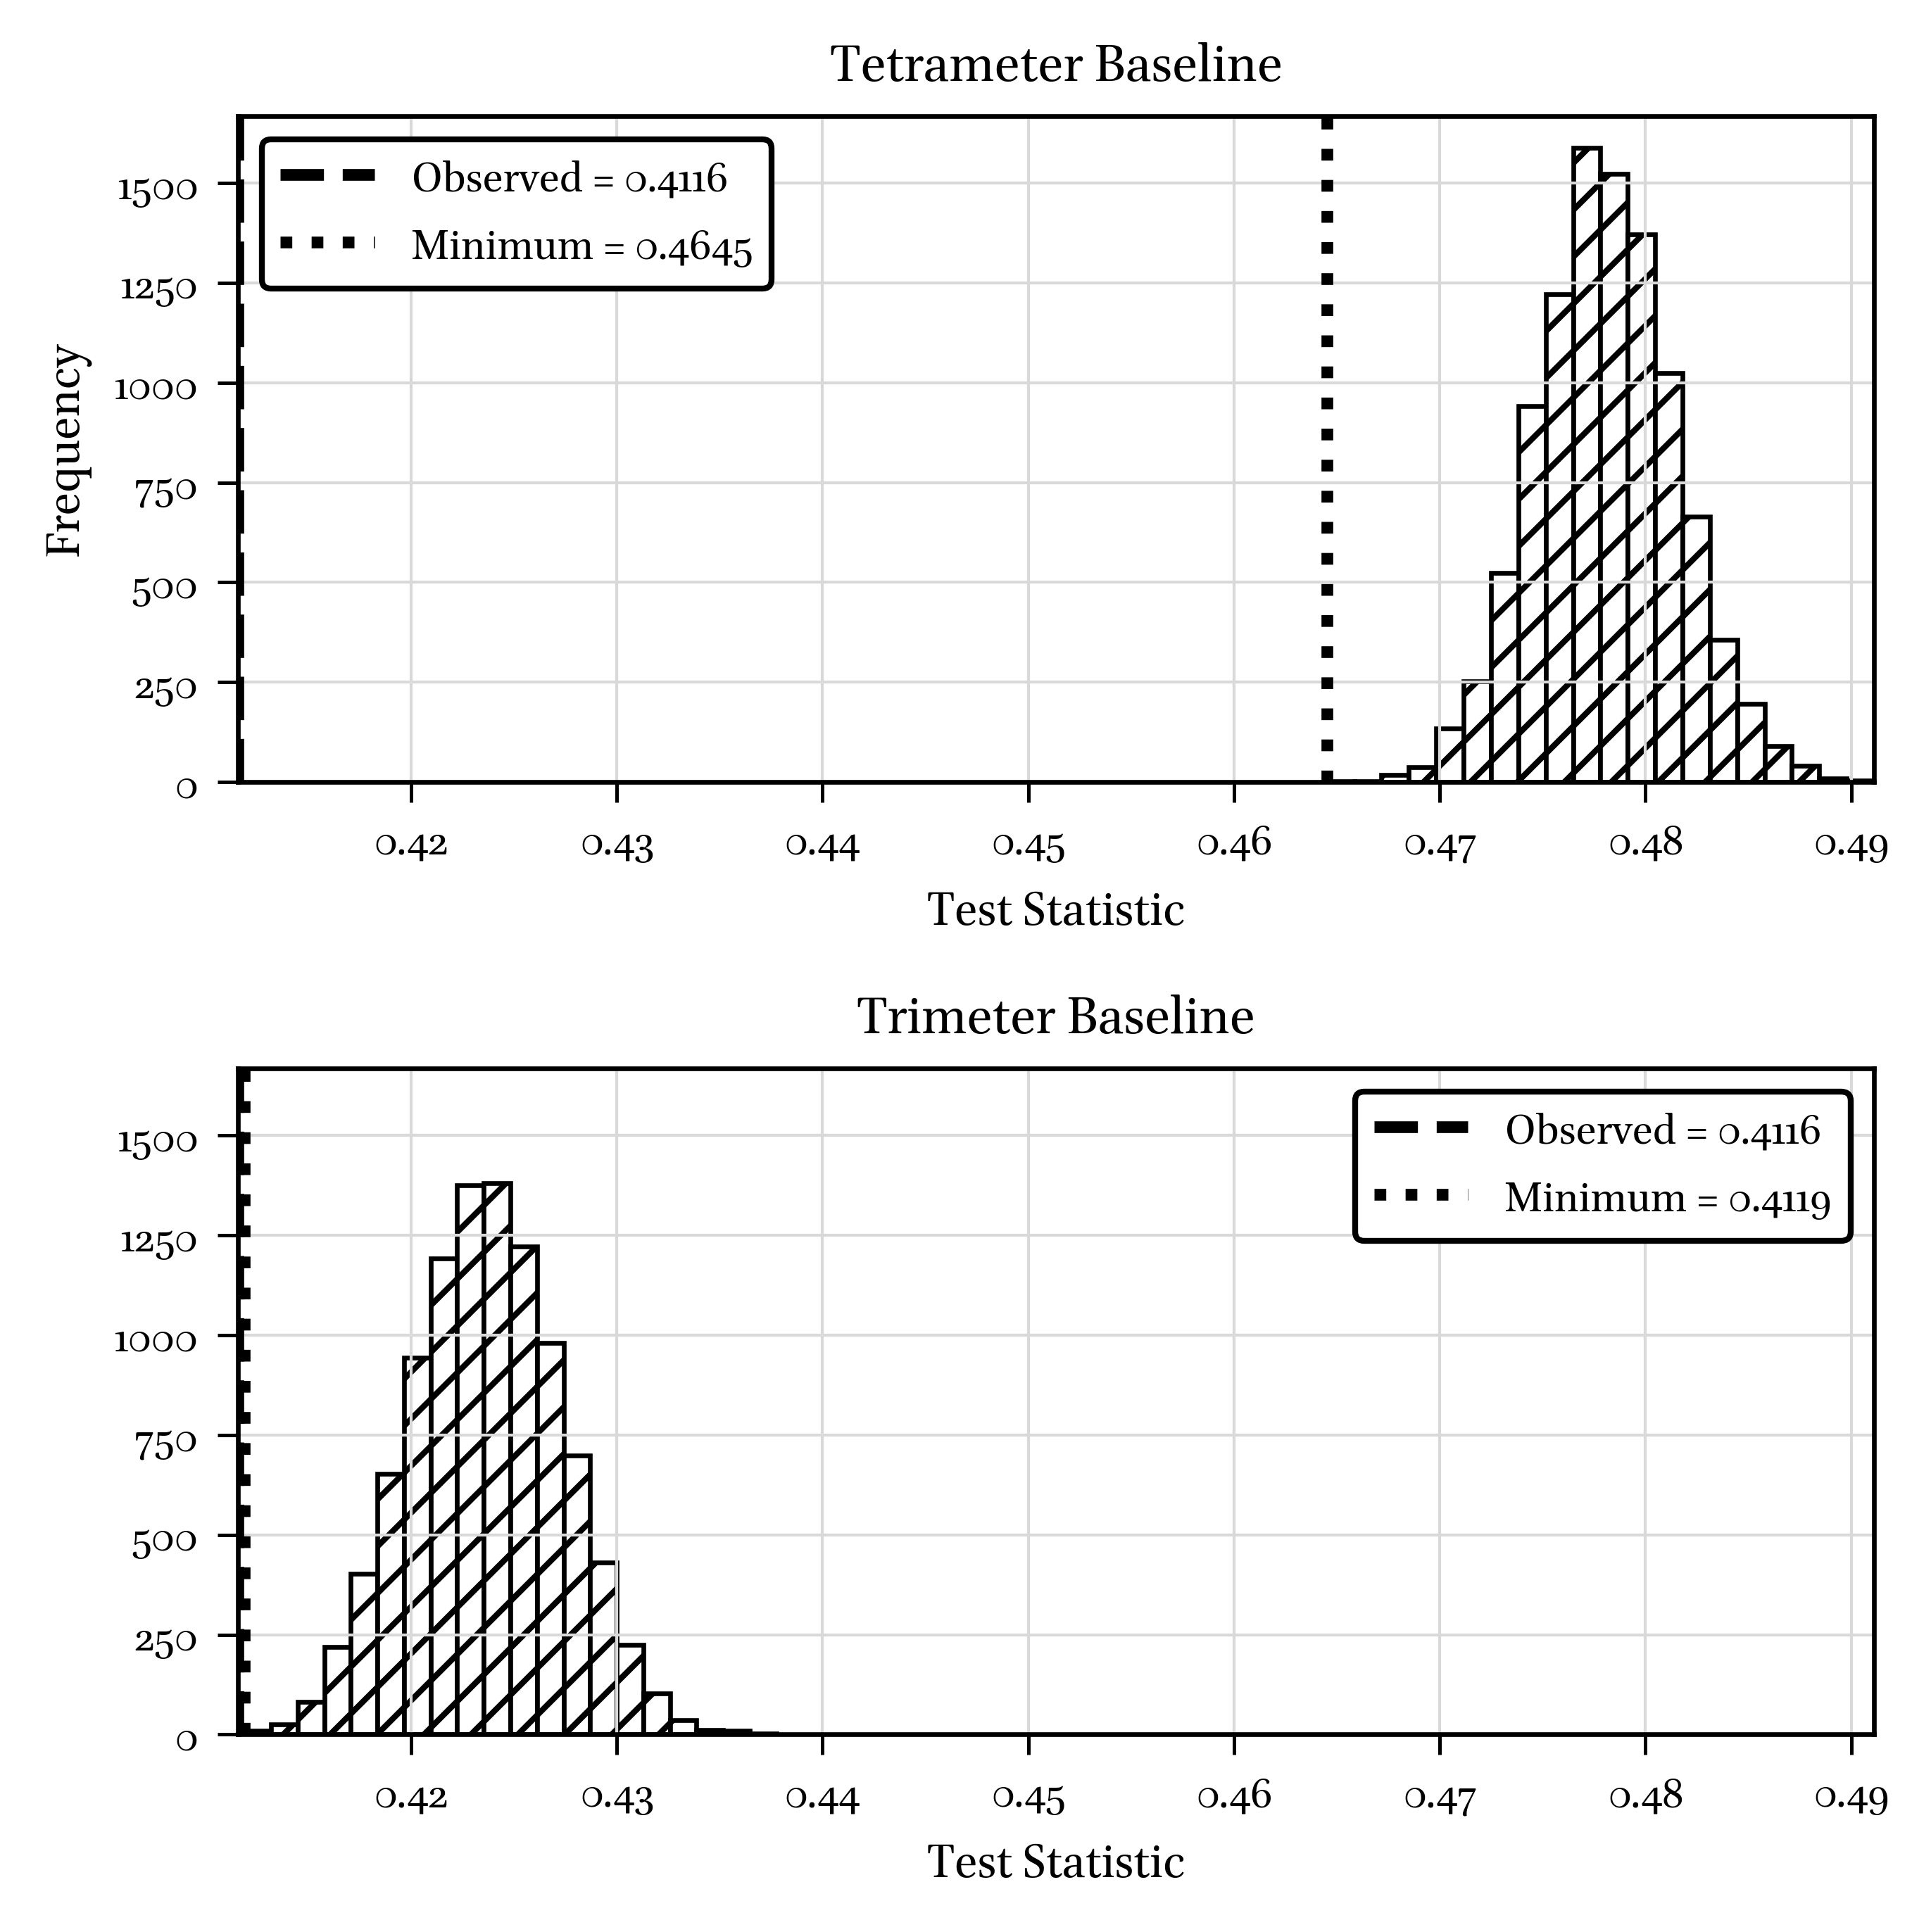

In [18]:
import matplotlib.pyplot as plt
import numpy as np

from responsio_accentuum import apply_bw_journal_style

apply_bw_journal_style()

# Convert to float arrays for plotting
T_exp_triads_tetrameter_arr = np.array(T_exp_triads_tetrameter, dtype=float)
T_exp_triads_trimeter_arr = np.array(T_exp_triads_trimeter, dtype=float)

# --- compute shared x-limits ---
xmin = min(
    np.min(T_exp_triads_tetrameter_arr),
    np.min(T_exp_triads_trimeter_arr),
    T_obs_triads,
)

xmax = max(
    np.max(T_exp_triads_tetrameter_arr),
    np.max(T_exp_triads_trimeter_arr),
    T_obs_triads,
)

fig, axes = plt.subplots(2, 1, sharey=True)

# --- histogram styling compatible with EPS + bw journal style ---
hist_kwargs = dict(
    bins=20,
    density=False,
    facecolor="white",
    edgecolor="black",
    hatch="///",
    linewidth=0.8,
)

# --- Tetrameter distribution ---
axes[0].hist(
    T_exp_triads_tetrameter_arr,
    **hist_kwargs,
)

axes[0].axvline(
    T_obs_triads,
    linestyle="--",
    linewidth=2,
    label=f"Observed = {T_obs_triads:.4f}",
)

axes[0].axvline(
    np.min(T_exp_triads_tetrameter_arr),
    linestyle=":",
    linewidth=2,
    label=f"Minimum = {np.min(T_exp_triads_tetrameter_arr):.4f}",
)

axes[0].set_title("Tetrameter Baseline")
axes[0].set_xlabel("Test Statistic")
axes[0].set_ylabel("Frequency")

axes[0].legend(
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1.0,
)

# --- Trimeter distribution ---
axes[1].hist(
    T_exp_triads_trimeter_arr,
    **hist_kwargs,
)

axes[1].axvline(
    T_obs_triads,
    linestyle="--",
    linewidth=2,
    label=f"Observed = {T_obs_triads:.4f}",
)

axes[1].axvline(
    np.min(T_exp_triads_trimeter_arr),
    linestyle=":",
    linewidth=2,
    label=f"Minimum = {np.min(T_exp_triads_trimeter_arr):.4f}",
)

axes[1].set_title("Trimeter Baseline")
axes[1].set_xlabel("Test Statistic")

axes[1].legend(
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1.0,
)

# --- shared x-limits ---
for ax in axes:
    ax.set_xlim(xmin, xmax)

plt.tight_layout()

plt.savefig(ROOT / "media/figures/aristophanes_baseline_distributions.eps")
plt.savefig(ROOT / "media/figures/aristophanes_baseline_distributions.svg")
plt.savefig(
    ROOT / "media/figures/aristophanes_baseline_distributions.png",
    dpi=600,
)

plt.show()